../../pickle-object/ttrpg_bgg_description_svd_table.csv

Loading existing SVD database: ../../pickle-object/ttrpg_bgg_description_svd_table.csv...

Applying L2 Normalization (Cosine Similarity)...

Calculating Metrics for k=2 through k=40...
Please wait, this will take a moment...

Tested k=02 | Silhouette: 0.1188 | C-H: 1375.20 | Inertia: 5696.60
Tested k=03 | Silhouette: 0.1468 | C-H: 1342.03 | Inertia: 5108.56
Tested k=04 | Silhouette: 0.1237 | C-H: 1130.25 | Inertia: 4838.78
Tested k=05 | Silhouette: 0.1496 | C-H: 1023.15 | Inertia: 4597.59
Tested k=06 | Silhouette: 0.1729 | C-H: 961.70 | Inertia: 4375.11
Tested k=07 | Silhouette: 0.1894 | C-H: 900.02 | Inertia: 4206.81
Tested k=08 | Silhouette: 0.2065 | C-H: 859.63 | Inertia: 4044.47
Tested k=09 | Silhouette: 0.2229 | C-H: 832.08 | Inertia: 3889.03
Tested k=10 | Silhouette: 0.2174 | C-H: 816.28 | Inertia: 3734.13
Tested k=11 | Silhouette: 0.2275 | C-H: 793.04 | Inertia: 3612.29
Tested k=12 | Silhouette: 0.1854 | C-H: 771.61 | Inertia: 3503.18
Tested k=13 | Silhouette: 0.1950 | C-H: 752.

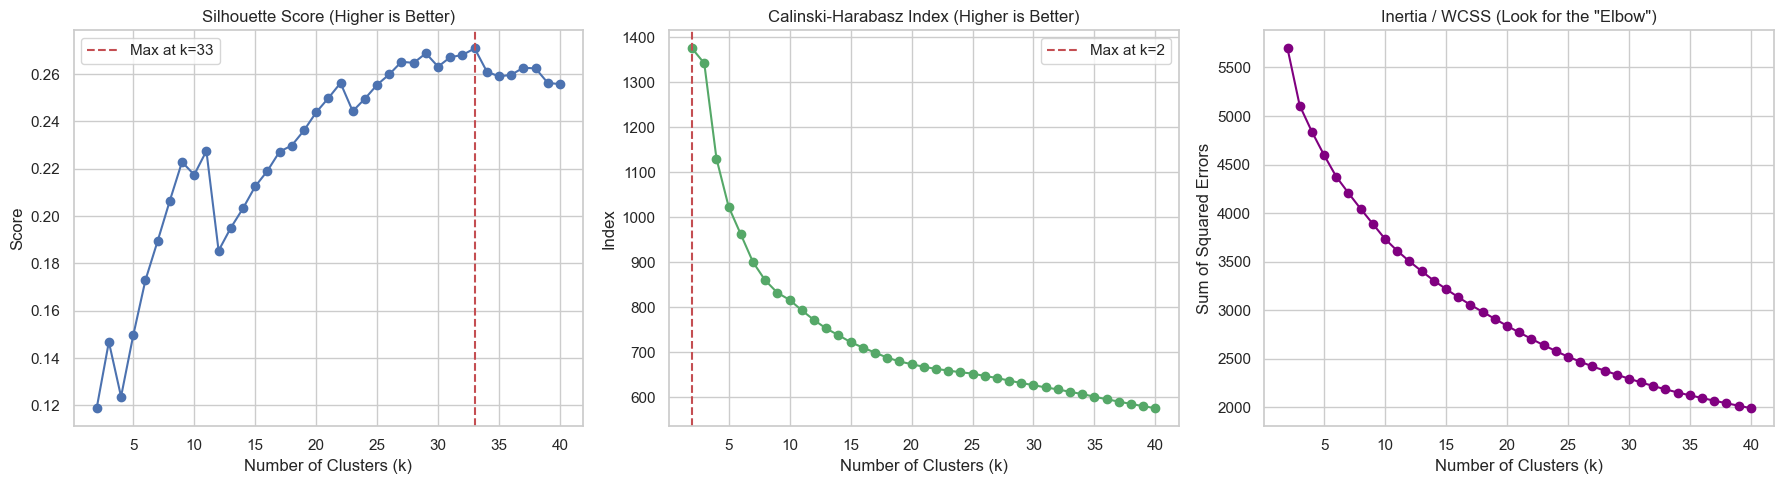


✅ Metric plots saved as 'cluster_defense_metrics.png'


In [ ]:
# K Means Clustering Evaluation for SVD Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD AND PREPARE EXISTING DATA
# ==========================================
target_file = '../../pickle-object/ttrpg_bgg_description_svd_table.csv'
print(f"Loading existing SVD database: {target_file}...\n")
df = pd.read_csv(target_file)

svd_cols = [f'SV_{i}' for i in range(1, 26)]
X = df[svd_cols].fillna(0)

print("Applying L2 Normalization (Cosine Similarity)...")
scaler = Normalizer(norm='l2')
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. HELPER FUNCTION: INERTIA (WCSS)
# ==========================================
# AgglomerativeClustering doesn't have a built-in 'inertia_' attribute like KMeans.
# We manually calculate the Within-Cluster Sum of Squares (WCSS) to find the 'Elbow'.
def calculate_wcss(X, labels):
    wcss = 0
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - centroid) ** 2)
    return wcss

# ==========================================
# 3. RUN MULTI-METRIC EVALUATION
# ==========================================
min_k = 2
max_k = 40
k_values = range(min_k, max_k + 1)

# Store results for the defense table
results = []

print(f"\nCalculating Metrics for k={min_k} through k={max_k}...")
print("Please wait, this will take a moment...\n")

for k in k_values:
    # Build the model
    agg_cluster = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg_cluster.fit_predict(X_scaled)
    
    # Calculate Metrics
    sil_score = silhouette_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    inertia_score = calculate_wcss(X_scaled, labels)
    
    # Append to results
    results.append({
        'k': k,
        'Silhouette Score': sil_score,
        'Calinski-Harabasz': ch_score,
        'Inertia (WCSS)': inertia_score
    })
    
    print(f"Tested k={k:02d} | Silhouette: {sil_score:.4f} | C-H: {ch_score:.2f} | Inertia: {inertia_score:.2f}")

# Convert results to a DataFrame for clean presentation
results_df = pd.DataFrame(results)

# ==========================================
# 4. PRINT THE DEFENSE TABLE
# ==========================================
print("\n" + "="*70)
print("              CLUSTER EVALUATION TABLE FOR DEFENSE")
print("="*70)
# Print a clean, markdown-style table
print(results_df.to_markdown(index=False, floatfmt=(".0f", ".4f", ".2f", ".2f")))
print("="*70)

# ==========================================
# 5. VISUALIZE THE 3 METRICS
# ==========================================
print("Generating evaluation plots...")
sns.set_theme(style="whitegrid")

# Create a 1x3 subplot grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Silhouette Score (Higher is better)
axes[0].plot(results_df['k'], results_df['Silhouette Score'], marker='o', color='b')
axes[0].set_title('Silhouette Score (Higher is Better)', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Score')
best_sil_k = results_df.loc[results_df['Silhouette Score'].idxmax(), 'k']
axes[0].axvline(x=best_sil_k, color='r', linestyle='--', label=f'Max at k={best_sil_k}')
axes[0].legend()

# Plot 2: Calinski-Harabasz Index (Higher is better)
axes[1].plot(results_df['k'], results_df['Calinski-Harabasz'], marker='o', color='g')
axes[1].set_title('Calinski-Harabasz Index (Higher is Better)', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Index')
best_ch_k = results_df.loc[results_df['Calinski-Harabasz'].idxmax(), 'k']
axes[1].axvline(x=best_ch_k, color='r', linestyle='--', label=f'Max at k={best_ch_k}')
axes[1].legend()

# Plot 3: Inertia / WCSS (Look for the Elbow)
axes[2].plot(results_df['k'], results_df['Inertia (WCSS)'], marker='o', color='purple')
axes[2].set_title('Inertia / WCSS (Look for the "Elbow")', fontsize=12)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Sum of Squared Errors')

plt.tight_layout()
plt.show()

print("\n✅ Metric plots saved as 'cluster_defense_metrics.png'")

In [47]:
# RUN ONCE

import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import Normalizer
import warnings

warnings.filterwarnings('ignore')

print("=== STARTING PHASE 1: MODEL TRAINING & EXPORT ===")

# ==========================================
# STEP 1: LOAD & PREPARE RAW DATA
# ==========================================
raw_file = '../../pickle-object/ttrpg_bgg_description_svd_table.csv'
print(f"\n1. Loading raw dataset: {raw_file}...")
df = pd.read_csv(raw_file)

svd_cols = [f'SV_{i}' for i in range(1, 26)]
X = df[svd_cols].fillna(0)

print("   Applying L2 Normalization (Cosine Similarity)...")
scaler = Normalizer(norm='l2')
X_scaled = scaler.fit_transform(X)

# ==========================================
# STEP 2: CLUSTERING (k=33)
# ==========================================
k = 33
print(f"\n2. Running Agglomerative Clustering (k={k})...")
clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
# Using True_Niche_ID to ensure perfectly clean column names across all files
df['True_Niche_ID'] = clusterer.fit_predict(X_scaled)

# ==========================================
# STEP 3: CALCULATE MATH & SCORES
# ==========================================
print("\n3. Calculating niche centroids and market competition scores...")
cluster_counts = df['True_Niche_ID'].value_counts()
min_size = cluster_counts.min()
max_size = cluster_counts.max()

# Calculate Scores
competition_scores = {}
for c_id, count in cluster_counts.items():
    score = (count - min_size) / (max_size - min_size) if max_size != min_size else 1.0
    competition_scores[c_id] = round(score, 4)

# Calculate Centroids
cluster_centroids = {}
for c_id in sorted(df['True_Niche_ID'].unique()):
    cluster_data = X_scaled[df['True_Niche_ID'] == c_id]
    cluster_centroids[c_id] = cluster_data.mean(axis=0)

# ==========================================
# STEP 4: EXPORT THE LIVE APP FILES
# ==========================================
print("\n4. Exporting files for the Live Production App...")

# --- EXPORT A: The "Math Brain" (33 rows) ---
ref_df = pd.DataFrame.from_dict(cluster_centroids, orient='index', columns=svd_cols)
ref_df['Competition_Score'] = pd.Series(competition_scores)
ref_df.index.name = 'Cluster_ID'
output_a = 'cluster_reference_data.csv'
ref_df.to_csv(output_a)
print(f"   ✅ Saved: {output_a} (The Mathematical Reference)")

# --- EXPORT B: The Full Categorized Dataset (10,000 rows) ---
output_b = 'ttrpg_true_niches_categorized.csv'
df.to_csv(output_b, index=False)
print(f"   ✅ Saved: {output_b} (The Master Backup)")

# --- EXPORT C: The Lightweight Competitor Dictionary (330 rows) ---
# Sort by Niche, then by most reviewed
sorted_df = df.sort_values(by=['True_Niche_ID', 'Number of Reviews'], ascending=[True, False])
cols_to_keep = ['True_Niche_ID', 'Name', 'Average Score', 'Number of Reviews']

# Extract top 10 per niche
comp_dict_df = sorted_df.groupby('True_Niche_ID', group_keys=False).head(10)[cols_to_keep]
output_c = 'competitor_dictionary.csv'
comp_dict_df.to_csv(output_c, index=False)
print(f"   ✅ Saved: {output_c} (The Fast-Lookup UI Dictionary)")

print("\n=== PHASE 1 COMPLETE! YOU ARE READY TO BUILD THE LIVE APP ===")

=== STARTING PHASE 1: MODEL TRAINING & EXPORT ===

1. Loading raw dataset: ../../pickle-object/ttrpg_bgg_description_svd_table.csv...
   Applying L2 Normalization (Cosine Similarity)...

2. Running Agglomerative Clustering (k=33)...

3. Calculating niche centroids and market competition scores...

4. Exporting files for the Live Production App...
   ✅ Saved: cluster_reference_data.csv (The Mathematical Reference)
   ✅ Saved: ttrpg_true_niches_categorized.csv (The Master Backup)
   ✅ Saved: competitor_dictionary.csv (The Fast-Lookup UI Dictionary)

=== PHASE 1 COMPLETE! YOU ARE READY TO BUILD THE LIVE APP ===


In [122]:
# PRODUCTION PIPELINE:

import pandas as pd
import numpy as np
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import euclidean_distances
import warnings

warnings.filterwarnings('ignore')

print("=== INITIALIZING LIVE APP SERVER ===")

# ==========================================
# STEP 1: LOAD THE "BRAIN" (Runs once on app startup)
# ==========================================
# Load the 33-row mathematical reference
ref_df = pd.read_csv('cluster_reference_data.csv', index_col='Cluster_ID')

# Load the 330-row lightweight dictionary
comp_dict = pd.read_csv('competitor_dictionary.csv')

# Extract coordinates and scores into fast arrays/dictionaries
svd_cols = [f'SV_{i}' for i in range(1, 26)]
centroids_matrix = ref_df[svd_cols].values
competition_scores = ref_df['Competition_Score'].to_dict()

# Initialize the normalizer (We use L2 to match how we trained the model)
scaler = Normalizer(norm='l2')

print("✅ App Ready. Waiting for user input...\n")

# ==========================================
# STEP 2: THE CORE PREDICTION ENGINE
# ==========================================
def predict_niche(new_svd_array):
    """Takes a 25-number array and instantly finds its market position."""
    # 1. Scale the user's input mathematically
    new_scaled = scaler.transform([new_svd_array])
    
    # 2. Measure distance to all 33 niches simultaneously
    distances = euclidean_distances(new_scaled, centroids_matrix)[0]
    
    # 3. Grab the closest Niche ID and its Competition Score
    closest_cluster_id = ref_df.index[np.argmin(distances)]
    comp_score = competition_scores[closest_cluster_id]
    
    return closest_cluster_id, comp_score

# ==========================================
# STEP 3: SIMULATING A USER SESSION
# ==========================================
# In your real app, this is where you take the user's text description 
# and pass it through your TF-IDF Vectorizer and SVD model.
# For now, we simulate a user landing in a moderately populated niche:
mock_user_input = np.random.normal(0, 1, 25) 

print(">> User submitted a new game concept. Analyzing...")

# Instantly predict
assigned_cluster, density_score = predict_niche(mock_user_input)

# ==========================================
# STEP 4: DISPLAY THE FINAL DASHBOARD
# ==========================================
print("\n" + "="*50)
print("             MARKET ANALYSIS REPORT")
print("="*50)
print(f"Target Demographic: Niche {assigned_cluster}")
print(f"Market Saturation:  {density_score:.4f} / 1.0000")

# Provide actionable business advice 
if density_score > 0.75:
    print("Market State:       RED OCEAN (High Competition)")
    print("Advice:             Highly saturated market. Requires a massive marketing budget or a truly unique twist to stand out.")
elif density_score < 0.25:
    print("Market State:       BLUE OCEAN (Low Competition)")
    print("Advice:             Wide open market. High chance to stand out, but ensure the target audience is large enough to sustain it.")
else:
    print("Market State:       STANDARD MARKET (Medium Competition)")
    print("Advice:             Healthy market viability. Standard competition rules apply.")

# Display direct competitors from the dictionary
print(f"\n=== TOP 10 DIRECT COMPETITORS ===")
top_competitors = comp_dict[comp_dict['True_Niche_ID'] == assigned_cluster]
print(top_competitors[['Name', 'Average Score', 'Number of Reviews']].to_string(index=False))
print("="*50)

=== INITIALIZING LIVE APP SERVER ===
✅ App Ready. Waiting for user input...

>> User submitted a new game concept. Analyzing...

             MARKET ANALYSIS REPORT
Target Demographic: Niche 11
Market Saturation:  0.0616 / 1.0000
Market State:       BLUE OCEAN (Low Competition)
Advice:             Wide open market. High chance to stand out, but ensure the target audience is large enough to sustain it.

=== TOP 10 DIRECT COMPETITORS ===
                                              Name  Average Score  Number of Reviews
                                   Mage Wars Arena        7.62000               7553
                        Players Handbook (AD&D 1e)        7.88668                473
         Masks of Nyarlathotep (3rd & 4th edition)        8.48392                227
                                       Rivoli 1797        7.67000                 83
             Pathfinder Roleplaying Game GM Screen        7.54551                 78
   Star Wars: Edge of the Empire Game Master's Kit